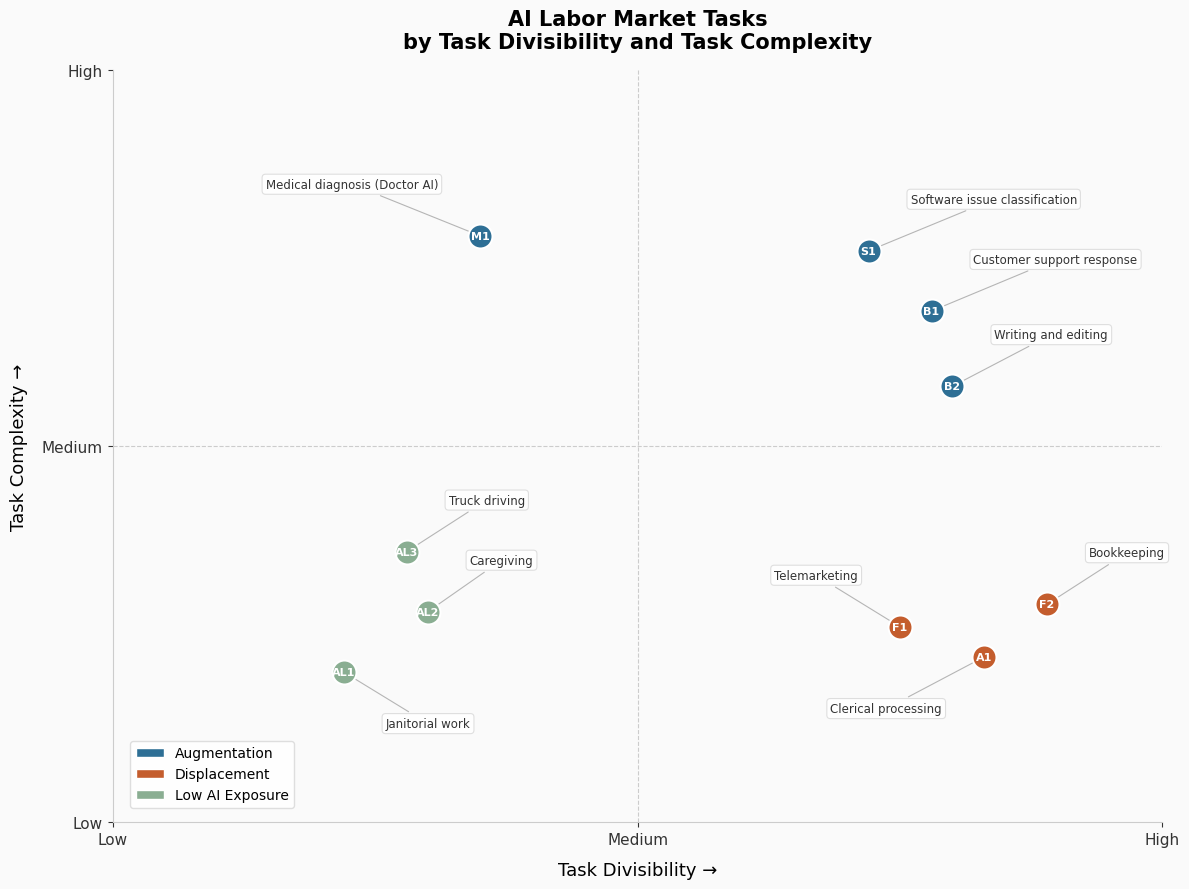

Saved to outputs\ai_task_matrix_final.png


In [49]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- Colors ---
BG_COLOR = "#fafafa"
GRID_COLOR = "#cccccc"
TEXT_COLOR = "#333333"

AUG_COLOR = "#2E6F95"     # Blue (augmentation)
DISP_COLOR = "#C45D2D"    # Red (displacement)
LOW_EXP_COLOR = "#8AAE92" # Green (low exposure)

fig, ax = plt.subplots(figsize=(12, 9))
ax.set_facecolor(BG_COLOR)
fig.patch.set_facecolor(BG_COLOR)

# --- Axis setup ---
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)

ax.set_xlabel("Task Divisibility →", fontsize=13, labelpad=10)
ax.set_ylabel("Task Complexity →", fontsize=13, labelpad=10)

ax.set_title(
    "AI Labor Market Tasks\nby Task Divisibility and Task Complexity",
    fontsize=15,
    fontweight="bold",
    pad=16,
)

ax.set_xticks([0, 5, 10])
ax.set_xticklabels(["Low", "Medium", "High"], fontsize=11)

ax.set_yticks([0, 5, 10])
ax.set_yticklabels(["Low", "Medium", "High"], fontsize=11)

# Midpoint lines
ax.axhline(5, color=GRID_COLOR, linewidth=0.8, linestyle="--", zorder=0)
ax.axvline(5, color=GRID_COLOR, linewidth=0.8, linestyle="--", zorder=0)

# --- Quadrant labels ---


# --- Tasks ---
tasks = [
    # --- Top-right (augmentation, high div + high complexity) ---
    {"abbrev": "B1", "label": "Customer support response", "x": 7.8, "y": 6.8, "color": AUG_COLOR, "dx": 0.4, "dy": 0.6, "ha": "left", "va": "bottom"},
    {"abbrev": "B2", "label": "Writing and editing", "x": 8.0, "y": 5.8, "color": AUG_COLOR, "dx": 0.4, "dy": 0.6, "ha": "left", "va": "bottom"},
    {"abbrev": "S1", "label": "Software issue classification", "x": 7.2, "y": 7.6, "color": AUG_COLOR, "dx": 0.4, "dy": 0.6, "ha": "left", "va": "bottom"},

    # --- Top-left (low div, high complexity) ---
    {"abbrev": "M1", "label": "Medical diagnosis (Doctor AI)", "x": 3.5, "y": 7.8, "color": AUG_COLOR, "dx": -0.4, "dy": 0.6, "ha": "right", "va": "bottom"},

    # --- Bottom-right (displacement) ---
    {"abbrev": "A1", "label": "Clerical processing", "x": 8.3, "y": 2.2, "color": DISP_COLOR, "dx": -0.4, "dy": -0.6, "ha": "right", "va": "top"},
    #{"abbrev": "A2", "label": "Production task", "x": 8.8, "y": 1.6, "color": DISP_COLOR, "dx": 0.4, "dy": -0.6, "ha": "left", "va": "top"},
    {"abbrev": "F1", "label": "Telemarketing", "x": 7.5, "y": 2.6, "color": DISP_COLOR, "dx": -0.4, "dy": 0.6, "ha": "right", "va": "bottom"},
    {"abbrev": "F2", "label": "Bookkeeping", "x": 8.9, "y": 2.9, "color": DISP_COLOR, "dx": 0.4, "dy": 0.6, "ha": "left", "va": "bottom"},

    # --- Bottom-left (low exposure) ---
    {"abbrev": "AL1", "label": "Janitorial work", "x": 2.2, "y": 2.0, "color": LOW_EXP_COLOR, "dx": 0.4, "dy": -0.6, "ha": "left", "va": "top"},
    {"abbrev": "AL2", "label": "Caregiving", "x": 3.0, "y": 2.8, "color": LOW_EXP_COLOR, "dx": 0.4, "dy": 0.6, "ha": "left", "va": "bottom"},
    {"abbrev": "AL3", "label": "Truck driving", "x": 2.8, "y": 3.6, "color": LOW_EXP_COLOR, "dx": 0.4, "dy": 0.6, "ha": "left", "va": "bottom"},
]

# --- Plot ---
for task in tasks:
    ax.scatter(
        task["x"], task["y"],
        s=300,
        color=task["color"],
        edgecolors="white",
        linewidths=1.5,
        zorder=5,
    )

    ax.text(
        task["x"], task["y"], task["abbrev"],
        ha="center", va="center",
        fontsize=8,
        fontweight="bold",
        color="white",
        zorder=6,
    )

    ax.annotate(
        task["label"],
        xy=(task["x"], task["y"]),
        xytext=(task["x"] + task["dx"], task["y"] + task["dy"]),
        ha=task["ha"],
        va=task["va"],
        fontsize=8.5,
        color=TEXT_COLOR,
        arrowprops=dict(arrowstyle="-", color="#b5b5b5", lw=0.8),
        bbox=dict(
            boxstyle="round,pad=0.3",
            fc="white",
            ec="#dddddd",
            lw=0.8,
            alpha=0.95,
        ),
    )

# --- Legend ---
legend_elements = [
    mpatches.Patch(facecolor=AUG_COLOR, edgecolor="white", label="Augmentation"),
    mpatches.Patch(facecolor=DISP_COLOR, edgecolor="white", label="Displacement"),
    mpatches.Patch(facecolor=LOW_EXP_COLOR, edgecolor="white", label="Low AI Exposure"),
]

ax.legend(
    handles=legend_elements,
    loc="lower left",
    bbox_to_anchor=(0.01, 0.01),
    fontsize=10,
    framealpha=0.95,
    edgecolor="#dddddd",
)

# Clean frame
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRID_COLOR)
ax.spines["bottom"].set_color(GRID_COLOR)

ax.tick_params(axis="both", colors=TEXT_COLOR)

plt.tight_layout()

# Save
output_dir = Path("outputs")
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / "ai_task_matrix_final.png"

plt.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved to {output_path}")

C:\Users\linds\AppData\Local\Temp\ipykernel_32304\1447402362.py:178: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


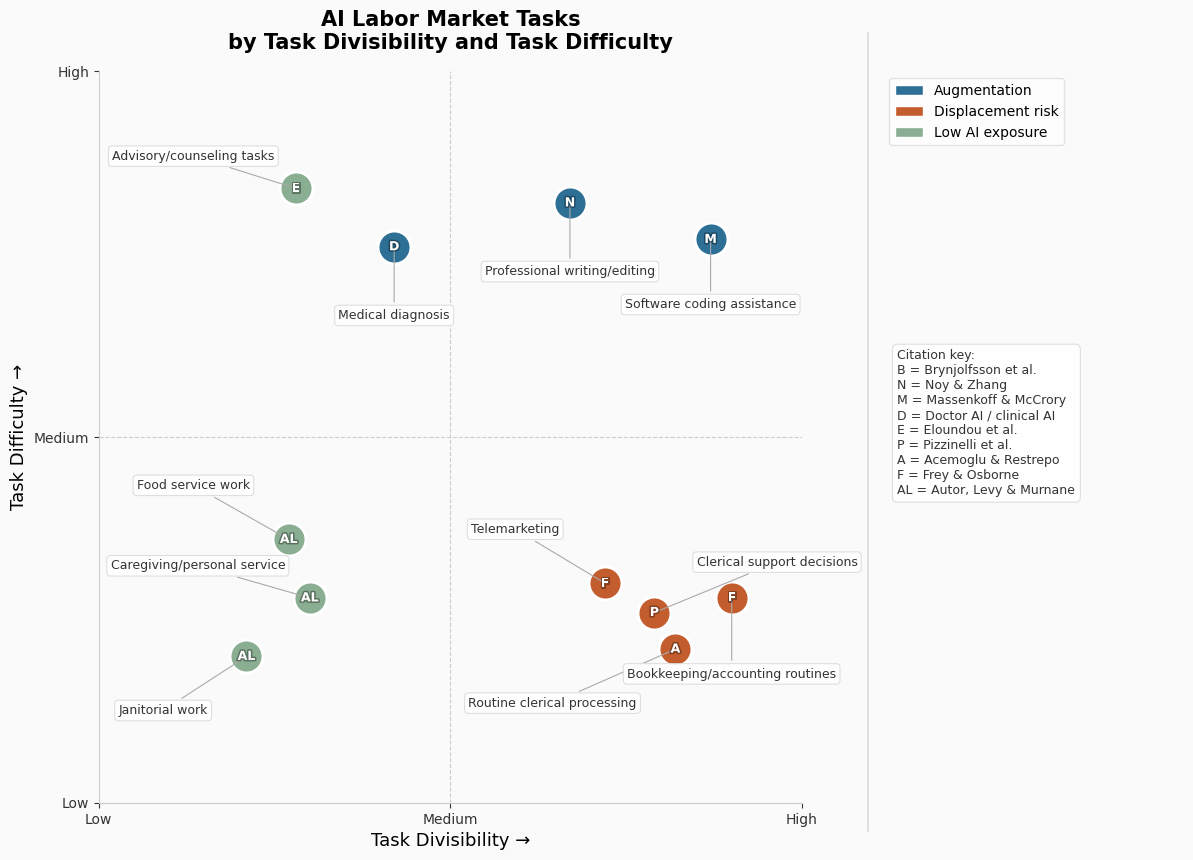

Saved to outputs\ai_task_matrix_final_updated.png


In [107]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as path_effects
from matplotlib.gridspec import GridSpec

# --- Colors ---
BG_COLOR = "#fafafa"
GRID_COLOR = "#cccccc"
TEXT_COLOR = "#333333"

AUG_COLOR = "#2E6F95"
DISP_COLOR = "#C45D2D"
LOW_EXP_COLOR = "#8AAE92"

# --- Figure with right panel ---
fig = plt.figure(figsize=(14, 9.5))
gs = GridSpec(1, 2, width_ratios=[4.2, 1.8], wspace=0.16)

ax = fig.add_subplot(gs[0, 0])
panel = fig.add_subplot(gs[0, 1])

ax.set_facecolor(BG_COLOR)
fig.patch.set_facecolor(BG_COLOR)
panel.axis("off")
panel.set_facecolor("#f3f3f3")
fig.add_artist(plt.Line2D([panel.get_position().x0 - 0.01, panel.get_position().x0 - 0.01], [0.08, 0.92], transform=fig.transFigure, color="#d6d6d6", linewidth=1.1))

# --- Axes setup ---
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)

ax.set_xlabel("Task Divisibility →", fontsize=13)
ax.set_ylabel("Task Difficulty →", fontsize=13)

ax.set_title(
    "AI Labor Market Tasks\nby Task Divisibility and Task Difficulty",
    fontsize=15,
    fontweight="bold",
    pad=16,
)

ax.set_xticks([0, 5, 10])
ax.set_xticklabels(["Low", "Medium", "High"])
ax.set_yticks([0, 5, 10])
ax.set_yticklabels(["Low", "Medium", "High"])

ax.axhline(5, linestyle="--", color=GRID_COLOR, linewidth=0.8)
ax.axvline(5, linestyle="--", color=GRID_COLOR, linewidth=0.8)

# --- Quadrant labels removed for cleaner presentation ---

# Tasks: code, label, x, y, color, (dx, dy), ha, va
tasks = [
    # --- High divisibility, high complexity: augmentation ---
    ("N", "Professional writing/editing", 6.7, 8.2, AUG_COLOR, (0.0, -0.85), "center", "top"),
    ("M", "Software coding assistance", 8.7, 7.7, AUG_COLOR, (0.0, -0.8), "center", "top"),

    # --- Low divisibility, high complexity: hard-to-decompose AI exposure ---
    ("D", "Medical diagnosis", 4.2, 7.6, AUG_COLOR, (0.0, -0.85), "center", "top"),
    ("E", "Advisory/counseling tasks", 2.8, 8.4, LOW_EXP_COLOR, (-0.3, 0.35), "right", "bottom"),

    # --- High divisibility, low complexity: displacement risk ---
    ("A", "Routine clerical processing", 8.2, 2.1, DISP_COLOR, (-0.55, -0.65), "right", "top"),
    ("F", "Telemarketing", 7.2, 3.0, DISP_COLOR, (-0.65, 0.65), "right", "bottom"),
    ("F", "Bookkeeping/accounting routines", 9.0, 2.8, DISP_COLOR, (0.0, -0.95), "center", "top"),
    ("P", "Clerical support decisions", 7.9, 2.6, DISP_COLOR, (0.6, 0.6), "left", "bottom"),

    # --- Low divisibility, low complexity: low AI exposure ---
    ("AL", "Janitorial work", 2.1, 2.0, LOW_EXP_COLOR, (-0.55, -0.65), "right", "top"),
    ("AL", "Caregiving/personal service", 3.0, 2.8, LOW_EXP_COLOR, (-0.35, 0.35), "right", "bottom"),
    ("AL", "Food service work", 2.7, 3.6, LOW_EXP_COLOR, (-0.55, 0.65), "right", "bottom"),
]

# --- Plot tasks ---
for code, label, x, y, color, (dx, dy), ha, va in tasks:
    ax.scatter(
        x, y,
        s=560,
        color=color,
        edgecolors="white",
        linewidths=2.0,
        zorder=5,
    )

    ax.text(
        x, y, code,
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold",
        color="white",
        zorder=7,
        path_effects=[
            path_effects.withStroke(
                linewidth=2.2,
                foreground="black",
                alpha=0.35,
            )
        ],
    )

    ax.annotate(
        label,
        xy=(x, y),
        xytext=(x + dx, y + dy),
        ha=ha,
        va=va,
        fontsize=9,
        color=TEXT_COLOR,
        arrowprops=dict(
            arrowstyle="-",
            color="#aaaaaa",
            lw=0.8,
        ),
        bbox=dict(
            boxstyle="round,pad=0.3",
            fc="white",
            ec="#dddddd",
            lw=0.8,
            alpha=0.95,
        ),
        zorder=6,
    )

# --- Legend in right panel ---
legend_elements = [
    mpatches.Patch(facecolor=AUG_COLOR, edgecolor="white", label="Augmentation"),
    mpatches.Patch(facecolor=DISP_COLOR, edgecolor="white", label="Displacement risk"),
    mpatches.Patch(facecolor=LOW_EXP_COLOR, edgecolor="white", label="Low AI exposure"),
]

panel.legend(
    handles=legend_elements,
    loc="upper left",
    fontsize=10,
    frameon=True,
    edgecolor="#dddddd",
)

# --- Citation key in right panel ---
citation_key = (
    "Citation key:\n"
    "B = Brynjolfsson et al.\n"
    "N = Noy & Zhang\n"
    "M = Massenkoff & McCrory\n"
    "D = Doctor AI / clinical AI\n"
    "E = Eloundou et al.\n"
    "P = Pizzinelli et al.\n"
    "A = Acemoglu & Restrepo\n"
    "F = Frey & Osborne\n"
    "AL = Autor, Levy & Murnane"
)

panel.text(
    0.05, 0.62,
    citation_key,
    fontsize=9,
    va="top",
    ha="left",
    color=TEXT_COLOR,
    bbox=dict(
        boxstyle="round,pad=0.4",
        fc="white",
        ec="#dddddd",
        lw=0.8,
        alpha=0.95,
    ),
)

# --- Clean frame ---
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRID_COLOR)
ax.spines["bottom"].set_color(GRID_COLOR)
ax.tick_params(axis="both", colors=TEXT_COLOR)

plt.tight_layout()

# --- Save ---
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)
output_path = output_dir / "ai_task_matrix_final_updated.png"

plt.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved to {output_path}")

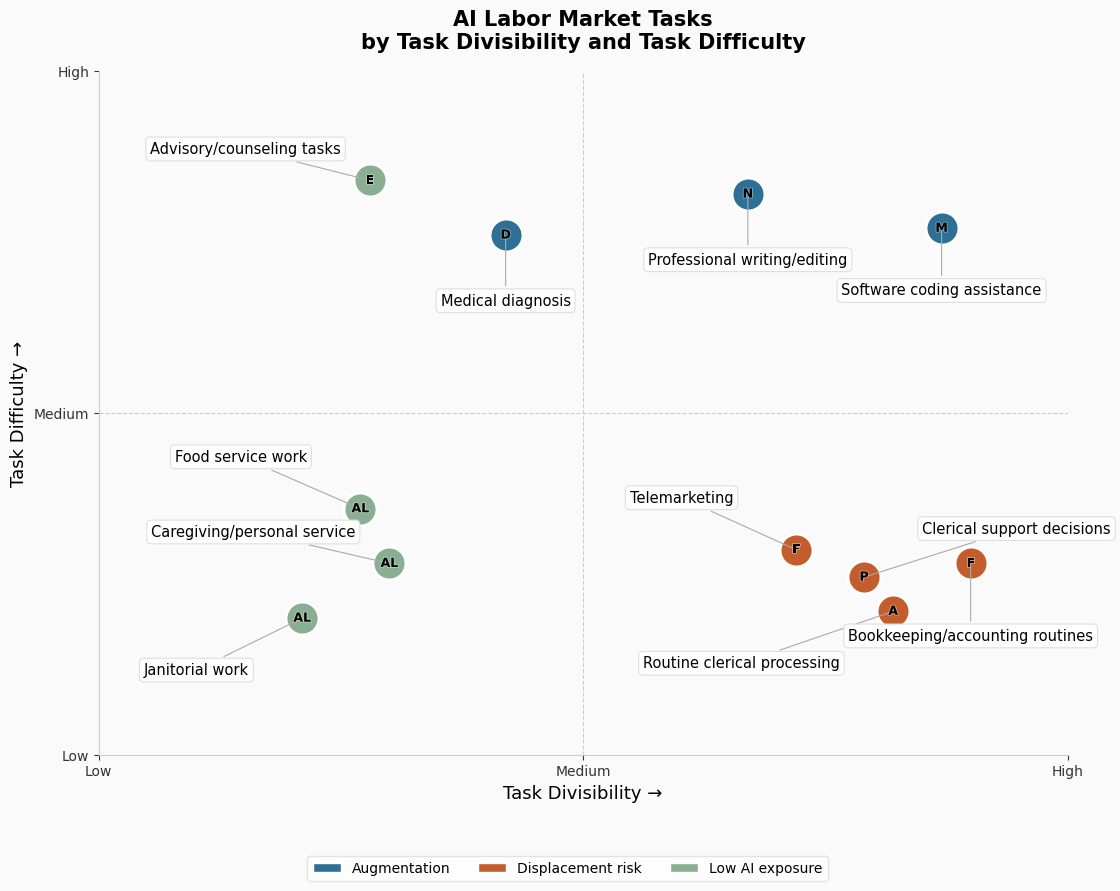

Saved to outputs\ai_task_matrix_final_updated.png


In [6]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as path_effects

# --- Colors ---
BG_COLOR = "#fafafa"
GRID_COLOR = "#cccccc"
TEXT_COLOR = "#333333"

AUG_COLOR = "#2E6F95"
DISP_COLOR = "#C45D2D"
LOW_EXP_COLOR = "#8AAE92"

# --- Figure ---
fig, ax = plt.subplots(figsize=(12.5, 9.5))
ax.set_facecolor(BG_COLOR)
fig.patch.set_facecolor(BG_COLOR)

# --- Axes setup ---
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)

ax.set_xlabel("Task Divisibility →", fontsize=13)
ax.set_ylabel("Task Difficulty →", fontsize=13)

ax.set_title(
    "AI Labor Market Tasks\nby Task Divisibility and Task Difficulty",
    fontsize=15,
    fontweight="bold",
    pad=16,
)

ax.set_xticks([0, 5, 10])
ax.set_xticklabels(["Low", "Medium", "High"])
ax.set_yticks([0, 5, 10])
ax.set_yticklabels(["Low", "Medium", "High"])

ax.axhline(5, linestyle="--", color=GRID_COLOR, linewidth=0.8)
ax.axvline(5, linestyle="--", color=GRID_COLOR, linewidth=0.8)

# Tasks: code, label, x, y, color, (dx, dy), ha, va
tasks = [
    # --- High divisibility, high complexity: augmentation ---
    ("N", "Professional writing/editing", 6.7, 8.2, AUG_COLOR, (0.0, -0.85), "center", "top"),
    ("M", "Software coding assistance", 8.7, 7.7, AUG_COLOR, (0.0, -0.8), "center", "top"),

    # --- Low divisibility, high complexity: hard-to-decompose AI exposure ---
    ("D", "Medical diagnosis", 4.2, 7.6, AUG_COLOR, (0.0, -0.85), "center", "top"),
    ("E", "Advisory/counseling tasks", 2.8, 8.4, LOW_EXP_COLOR, (-0.3, 0.35), "right", "bottom"),

    # --- High divisibility, low complexity: displacement risk ---
    ("A", "Routine clerical processing", 8.2, 2.1, DISP_COLOR, (-0.55, -0.65), "right", "top"),
    ("F", "Telemarketing", 7.2, 3.0, DISP_COLOR, (-0.65, 0.65), "right", "bottom"),
    ("F", "Bookkeeping/accounting routines", 9.0, 2.8, DISP_COLOR, (0.0, -0.95), "center", "top"),
    ("P", "Clerical support decisions", 7.9, 2.6, DISP_COLOR, (0.6, 0.6), "left", "bottom"),

    # --- Low divisibility, low complexity: low AI exposure ---
    ("AL", "Janitorial work", 2.1, 2.0, LOW_EXP_COLOR, (-0.55, -0.65), "right", "top"),
    ("AL", "Caregiving/personal service", 3.0, 2.8, LOW_EXP_COLOR, (-0.35, 0.35), "right", "bottom"),
    ("AL", "Food service work", 2.7, 3.6, LOW_EXP_COLOR, (-0.55, 0.65), "right", "bottom"),
]

# --- Plot tasks ---
for code, label, x, y, color, (dx, dy), ha, va in tasks:
    ax.scatter(
        x, y,
        s=560,
        color=color,
        edgecolors="white",
        linewidths=2.0,
        zorder=5,
    )

    ax.text(
        x, y, code,
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold",
        color="black",
        zorder=7,
        path_effects=[
            path_effects.withStroke(
                linewidth=1.4,
                foreground="white",
                alpha=0.35,
            )
        ],
    )

    ax.annotate(
        label,
        xy=(x, y),
        xytext=(x + dx, y + dy),
        ha=ha,
        va=va,
        fontsize=10.5,
        color="black",
        arrowprops=dict(
            arrowstyle="-",
            color="#aaaaaa",
            lw=0.8,
        ),
        bbox=dict(
            boxstyle="round,pad=0.3",
            fc="white",
            ec="#dddddd",
            lw=0.8,
            alpha=0.95,
        ),
        zorder=6,
    )

# --- Legend below figure ---
legend_elements = [
    mpatches.Patch(facecolor=AUG_COLOR, edgecolor="white", label="Augmentation"),
    mpatches.Patch(facecolor=DISP_COLOR, edgecolor="white", label="Displacement risk"),
    mpatches.Patch(facecolor=LOW_EXP_COLOR, edgecolor="white", label="Low AI exposure"),
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=3,
    fontsize=10,
    frameon=True,
    edgecolor="#dddddd",
)

# --- Clean frame ---
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRID_COLOR)
ax.spines["bottom"].set_color(GRID_COLOR)
ax.tick_params(axis="both", colors=TEXT_COLOR)

fig.subplots_adjust(bottom=0.16)

# --- Save ---
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)
output_path = output_dir / "ai_task_matrix_final_updated.png"

plt.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved to {output_path}")